In [4]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [5]:
#Summerize the data
df.info()
# print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [6]:
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


Analyze the relationship between years of professional coding experience (`YearsCodePro`) and job satisfaction (`JobSat`).

In [7]:
subset_df = df[['JobSat', 'YearsCodePro']].copy()
subset_df = subset_df.dropna(subset=['JobSat', 'YearsCodePro'])

subset_df['YearsCodePro'] = subset_df['YearsCodePro'].replace("Less than 1 year",0)
subset_df['YearsCodePro'] = subset_df['YearsCodePro'].replace("More than 50 years",55)

subset_df['YearsCodePro'] = subset_df['YearsCodePro'].astype(int)
# subset_df.dtypes



In [8]:
# Define experience ranges
bins = [0, 5, 10,15, 20,25,30,35,40,45,50, float('inf')] 
labels = ['0-5', '5-10', '10-15', '15-20','20-25','23-30','30-35','35-40','40-45','45-50','>50']  
subset_df['Experience_Range'] = pd.cut(subset_df['YearsCodePro'], bins=bins, labels=labels, right=False)

# Calculate median Job Satisfaction for each experience range
median_satisfaction = subset_df.groupby('Experience_Range',observed=True)['JobSat'].median()


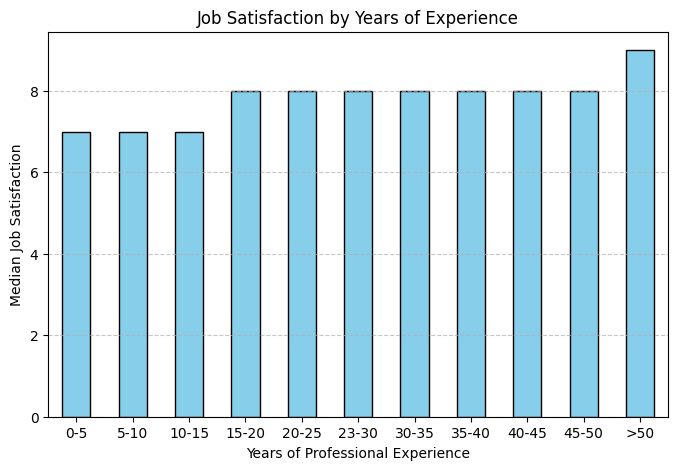

In [9]:
# Plot Bar Chart
plt.figure(figsize=(8, 5))
median_satisfaction.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Years of Professional Experience')
plt.ylabel('Median Job Satisfaction')
plt.title('Job Satisfaction by Years of Experience')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

count plot to show the distribution of `JobSat` values

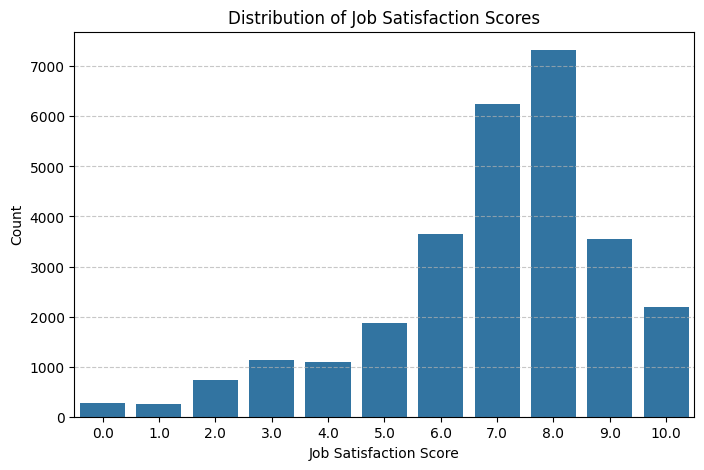

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=subset_df, x='JobSat')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Count')
plt.title('Distribution of Job Satisfaction Scores')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Analyze trends in remote work based on job roles. Use the `RemoteWork` and `Employment` columns to explore preferences and examine if specific job roles prefer remote work more than others

In [11]:
subset_df2 = df[['Employment', 'RemoteWork']].copy()
#Filter the rows with Employed
subset_df2 = subset_df2[subset_df2['Employment'].str.contains('Employed, full-time|Employed, part-time', regex=True, na=False)].copy()
# Create a new column for employment type
subset_df2['Employment_Type'] = subset_df2['Employment'].apply(
    lambda x: 'Full-time' if 'Employed, full-time' in x else 'Part-time'
)
subset_df2['RemoteWork'].fillna("In-person")



0                                      Remote
1                                      Remote
2                                      Remote
6                                      Remote
8                                   In-person
                         ...                 
65431    Hybrid (some remote, some in-person)
65432                                  Remote
65433                                  Remote
65434                               In-person
65435    Hybrid (some remote, some in-person)
Name: RemoteWork, Length: 48801, dtype: object

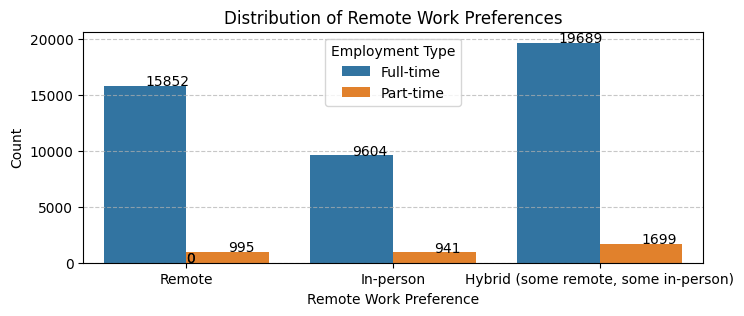

In [12]:
# Plot Count Plot for Remote Work Distribution
plt.figure(figsize=(8, 3))
ax = sns.countplot(data=subset_df2, x='RemoteWork', hue='Employment_Type')
# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}' , 
                (p.get_x() + p.get_width() / 2., p.get_height()),)
plt.xlabel('Remote Work Preference')
plt.ylabel('Count')
plt.title('Distribution of Remote Work Preferences')
plt.legend(title='Employment Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
remote_work_ct = pd.crosstab(subset_df2['RemoteWork'],subset_df2['Employment_Type'])
remote_work_ct

Employment_Type,Full-time,Part-time
RemoteWork,,
"Hybrid (some remote, some in-person)",19689,1699
In-person,9604,941
Remote,15852,995


Analyze the popularity of programming languages by region. Use the `LanguageHaveWorkedWith` column to investigate which languages are most used in different regions.

In [14]:
subset_df3 = df[['LanguageHaveWorkedWith', 'Country']].copy()
subset_df3 = subset_df3.dropna(subset=['LanguageHaveWorkedWith'])
df_expanded = subset_df3.assign(Language=df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')
language_region_counts = df_expanded.groupby(['Country', 'Language']).size().unstack(fill_value=0)

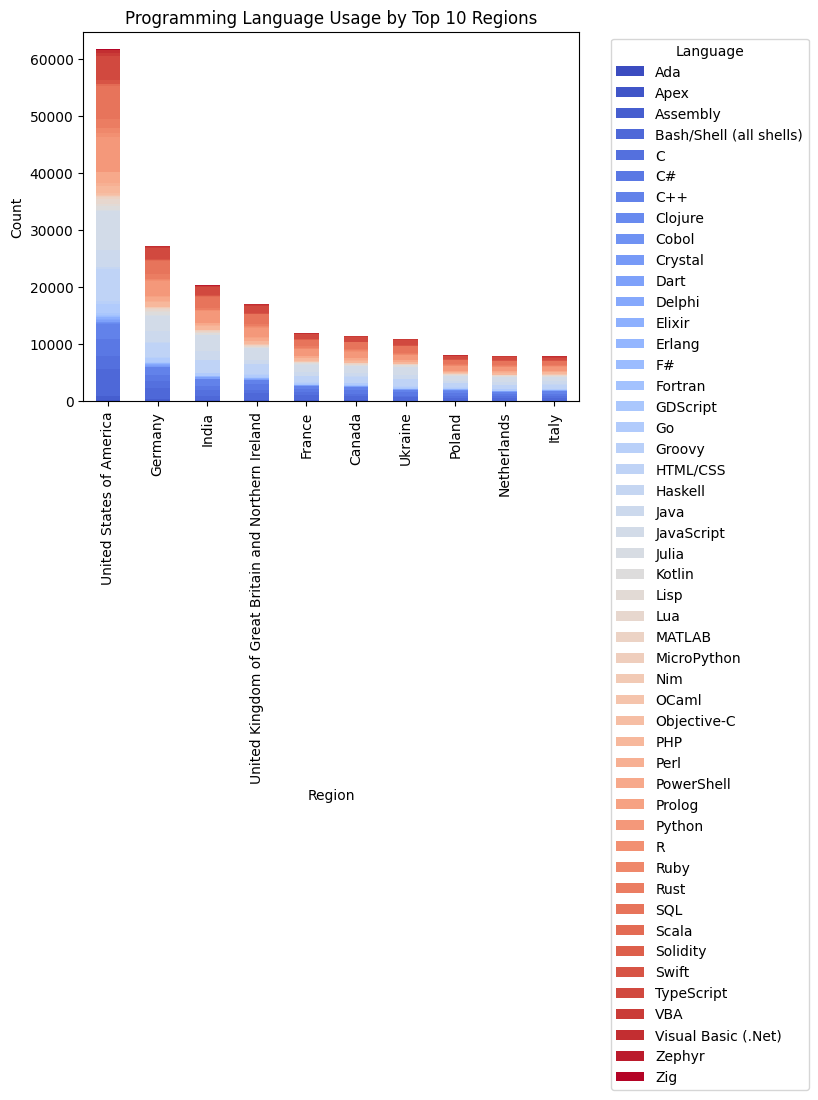

In [15]:
# Plot Stacked Bar Chart for Top 10 Regions
top_regions = language_region_counts.sum(axis=1).nlargest(10).index
language_region_counts.loc[top_regions].plot(kind='bar', stacked=True, colormap="coolwarm")

plt.xlabel('Region')
plt.ylabel('Count')
plt.title('Programming Language Usage by Top 10 Regions')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Examine how years of experience (`YearsCodePro`) correlate with job satisfaction (`JobSat`). Use a scatter plot to visualize this relationship.


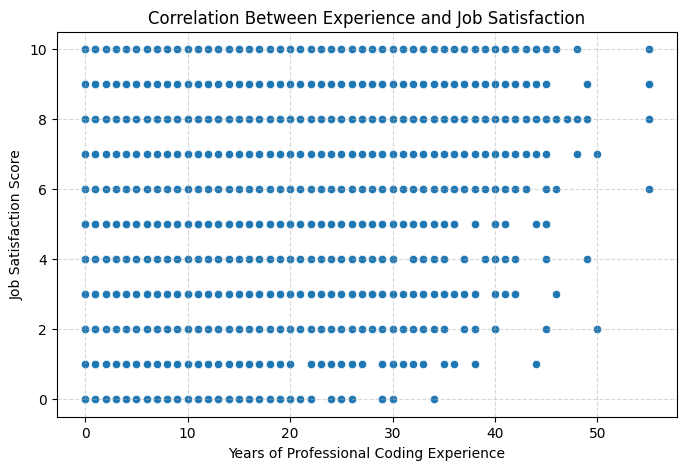

In [16]:
subset_df.head()
# Scatter Plot: Years of Experience vs. Job Satisfaction
plt.figure(figsize=(8, 5))
sns.scatterplot(data=subset_df, x='YearsCodePro', y='JobSat')

plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Job Satisfaction Score')
plt.title('Correlation Between Experience and Job Satisfaction')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Explore how educational background (`EdLevel`) relates to employment type (`Employment`). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.


In [17]:
def categorize_employment(status):
    if "Not employed" in status or "Retired" in status:
        return "not employed"
    elif "freelancer" in status:
        return "freelancer"
    elif "Employed, full-time" or "Student, full-time"  in status:
        return "Employed"
    else:
        return "others"


In [18]:
subset_df4 = df[['EdLevel', 'Employment']].copy()
subset_df4['EdLevel'] = subset_df4['EdLevel'].str.replace("â€™","",regex=False)
subset_df4['Employment_Status'] = subset_df4['Employment'].apply(categorize_employment)
subset_df4['EdLevel'] = subset_df4['EdLevel'].str.replace(r'\s*\(.*?\)', '', regex=True)
# subset_df4.head(30)


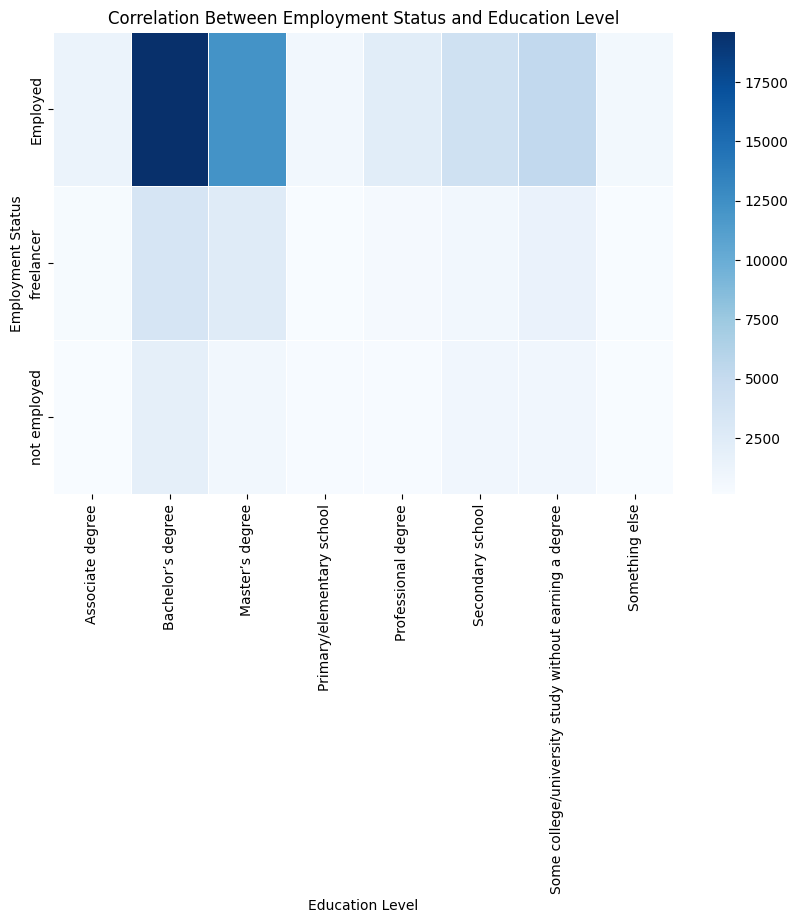

In [19]:
# cross-tabulation table
employment_education_ct = pd.crosstab(subset_df4['Employment_Status'], subset_df4['EdLevel'])
plt.figure(figsize=(10, 6))
sns.heatmap(employment_education_ct, cmap="Blues", linewidths=0.5, cbar=True, annot=False)
plt.xlabel('Education Level')
plt.ylabel('Employment Status')
plt.title('Correlation Between Employment Status and Education Level')
plt.show()

Explore how respondents are distributed across different industries

C:\Users\Amir\AppData\Local\Temp\ipykernel_16356\424495982.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.index, y=industry_counts.values, palette="coolwarm")


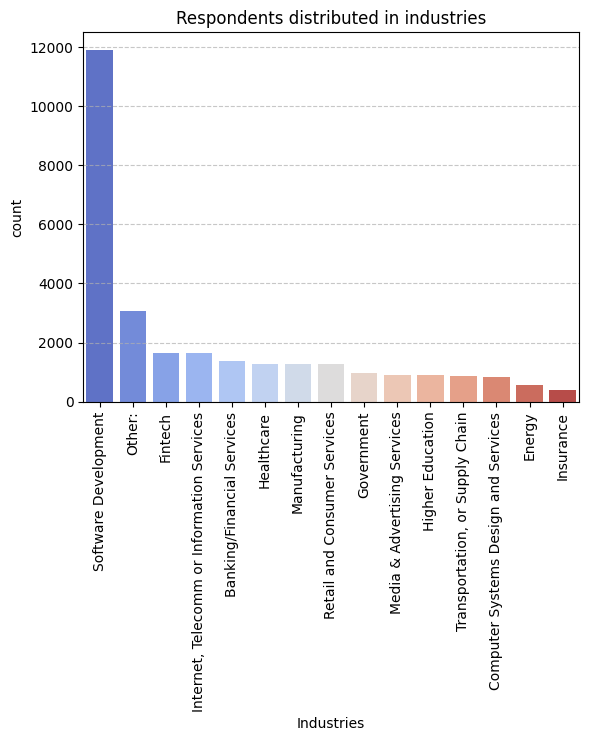

In [24]:
subset_df5 = df[['Industry']].copy()
subset_df5 = subset_df5.dropna(subset=['Industry'])
industry_counts = subset_df5['Industry'].value_counts()
sns.barplot(x=industry_counts.index, y=industry_counts.values, palette="coolwarm")
plt.xlabel('Industries')
plt.ylabel('count')
plt.title('Respondents distributed in industries')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()